# Customer Segmentation Feature Engineering
Takes user features and runs K-Means segmentation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os

df = pd.read_csv('../../data/precomputed/user_features.csv')

## Scaling and K-Means
Scale features and find elbow to justify k=4.

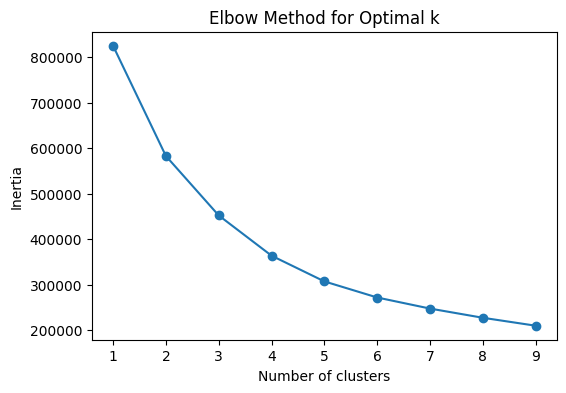

In [2]:
features_to_scale = ['days_since_prior_order', 'order_number', 'avg_basket_size', 'avg_reorder_rate']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features_to_scale])

inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

## Assign Clusters
Dormant, At-Risk, Regular, Champion.

- **Champion**: High frequency, high basket size, low recency (recent orders).
- **Regular**: Medium frequency, steady orders.
- **At-Risk**: Lower frequency, starting to churn.
- **Dormant**: Very high recency (haven't ordered in a long time).

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_id'] = kmeans.fit_predict(scaled_data)

# Simple heuristic mapping based on centroids (in practice, inspect centroids to map correctly)
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features_to_scale)
centroids['cluster_id'] = centroids.index
centroids = centroids.sort_values('days_since_prior_order')

labels = ['champion', 'regular', 'at-risk', 'dormant']
mapping = {centroids.iloc[i]['cluster_id']: labels[i] for i in range(4)}
df['segment'] = df['cluster_id'].map(mapping)

In [5]:
import seaborn as sns

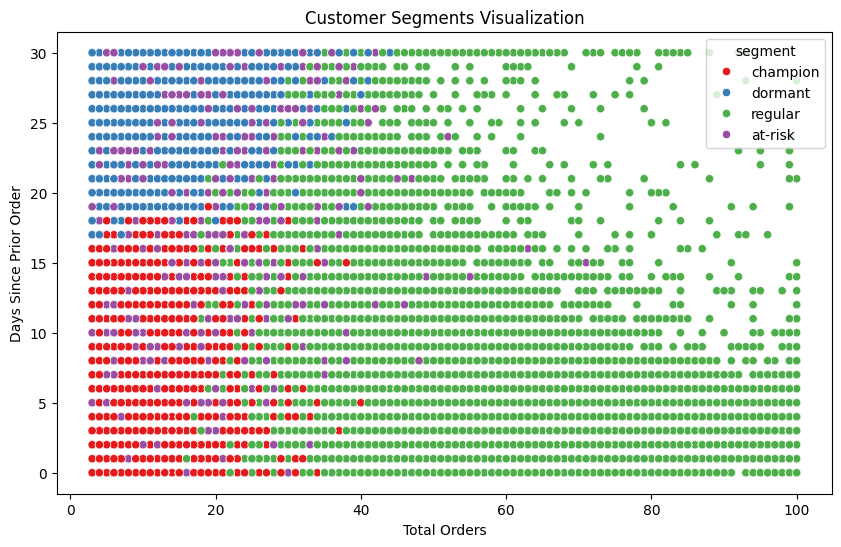

In [6]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='order_number',
    y='days_since_prior_order',
    hue='segment',
    palette='Set1'
)

plt.title('Customer Segments Visualization')
plt.xlabel('Total Orders')
plt.ylabel('Days Since Prior Order')

plt.show()